### Matthew Emmanuel Lurin Shopee Assessment Data Exploration

#### Start by importing Pandas for exploring the 100k customers dataset and loading to see the data points

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('customers-100000.csv')
df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,ffeCAb7AbcB0f07,Jared,Jarvis,Sanchez-Fletcher,Hatfieldshire,Eritrea,274.188.8773x41185,001-215-760-4642x969,gabriellehartman@benjamin.com,2021-11-11,https://www.mccarthy.info/
1,2,b687FfC4F1600eC,Marie,Malone,Mckay PLC,Robertsonburgh,Botswana,283-236-9529,(189)129-8356x63741,kstafford@sexton.com,2021-05-14,http://www.reynolds.com/
2,3,9FF9ACbc69dcF9c,Elijah,Barrera,Marks and Sons,Kimbury,Barbados,8252703789,459-916-7241x0909,jeanettecross@brown.com,2021-03-17,https://neal.com/
3,4,b49edDB1295FF6E,Sheryl,Montgomery,"Kirby, Vaughn and Sanders",Briannaview,Antarctica (the territory South of 60 deg S),425.475.3586,(392)819-9063,thomassierra@barrett.com,2020-09-23,https://www.powell-bryan.com/
4,5,3dcCbFEB17CCf2E,Jeremy,Houston,Lester-Manning,South Brianna,Micronesia,+1-223-666-5313x4530,252-488-3850x692,rubenwatkins@jacobs-wallace.info,2020-09-18,https://www.carrillo.com/


At first glance, we can see that the phone number formats are messy and not usable in the raw state, need to process the data first before being able to use it meaningfully, I'll move on to the general data structure, data types, and data quality and duplicate checks first

In [4]:
print(df.info(verbose=True))
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Index              100000 non-null  int64 
 1   Customer Id        100000 non-null  object
 2   First Name         100000 non-null  object
 3   Last Name          100000 non-null  object
 4   Company            100000 non-null  object
 5   City               100000 non-null  object
 6   Country            100000 non-null  object
 7   Phone 1            100000 non-null  object
 8   Phone 2            100000 non-null  object
 9   Email              100000 non-null  object
 10  Subscription Date  100000 non-null  object
 11  Website            100000 non-null  object
dtypes: int64(1), object(11)
memory usage: 9.2+ MB
None
(100000, 12)


In [5]:
df['Full Name'] = df['First Name'] + ' ' + df['Last Name']
print("Duplicated Customer IDs: ", df['Customer Id'].duplicated().sum())
print("Duplicated Emails: ", df['Email'].duplicated().sum())
print("Duplicated Phone Numbers: ", df['Phone 1'].duplicated().sum())
print("Duplicated Website URLs: ", df['Website'].duplicated().sum())
print("Duplicated Full Names: ", df['Full Name'].duplicated().sum())

Duplicated Customer IDs:  0
Duplicated Emails:  5
Duplicated Phone Numbers:  0
Duplicated Website URLs:  49529
Duplicated Full Names:  7056


#### Data structure is relatively clean, no null objects, there are 0 duplicated customer IDs and Phone numbers, but there are 5 duplicated emails, 49k repeated websites, and 7056 reused full names above, we can use this insight and explore this further

In [6]:
df[df['Email'].duplicated(keep=False)]

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Full Name
18196,18197,EdAD6f6E81F68Fc,Alison,Archer,Scott-Buchanan,Port Louisview,Central African Republic,768.406.8659x43604,+1-100-273-2543x287,kwalls@white.com,2020-08-02,https://www.jensen.info/,Alison Archer
30556,30557,b0E5A8E4E2beF72,Tammy,Ramirez,Horne PLC,West Dennis,Sweden,+1-038-417-7519,+1-325-182-4881,vgeorge@mendoza.com,2022-04-17,https://horton.com/,Tammy Ramirez
31997,31998,B29Fb3EF18604f8,Jaclyn,Torres,"Valencia, Newton and Carroll",Grahamchester,Kyrgyz Republic,626-732-3135x08645,+1-427-189-3094x844,ushields@saunders.com,2020-10-30,http://quinn.com/,Jaclyn Torres
71528,71529,b6Bcf35CE3e63b6,Kenneth,Mcpherson,Fuentes-Conrad,New Markland,Finland,001-705-413-9892x527,693.786.5328,vgeorge@mendoza.com,2021-12-19,http://hobbs-campbell.com/,Kenneth Mcpherson
73003,73004,C2DB1665c793Df8,Cristina,Cox,"Meyer, Davenport and Bailey",New Andreaburgh,Montenegro,0846366325,(499)958-9874,ushields@saunders.com,2021-04-29,http://www.baldwin-shepard.com/,Cristina Cox
85112,85113,5BcEBD82eBFf102,Charles,Freeman,"Barry, Gaines and Carroll",West Paulachester,American Samoa,236.552.5818x755,001-769-131-3193x577,imitchell@church.com,2021-02-21,https://boyer.com/,Charles Freeman
90751,90752,8A2E9e5af981CBd,Alvin,Stephens,Bolton-Torres,New Rose,Liechtenstein,2986388860,+1-337-311-2845x19687,julia03@briggs.com,2022-05-16,http://cortez.info/,Alvin Stephens
93818,93819,DDdA80d1beD99b6,Joshua,Gallegos,Richards LLC,Cameronport,El Salvador,(258)418-2361,+1-921-284-1924x04056,imitchell@church.com,2020-10-08,http://www.parks.net/,Joshua Gallegos
95616,95617,d44BCA84DEAf5EB,Lindsey,Carson,Boyd-Mcneil,Guyview,Dominica,578-691-0803x5139,+1-775-538-6716,kwalls@white.com,2020-04-13,https://www.marsh.org/,Lindsey Carson
96681,96682,64ff4a97cCF99Da,Kathy,Rojas,Burke-Schroeder,Reginaldland,Ghana,001-570-596-7205x878,152.042.4114x03141,julia03@briggs.com,2020-04-17,http://www.adkins-carney.com/,Kathy Rojas


In [7]:
df[df['Email'] == 'kwalls@white.com']

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Full Name
18196,18197,EdAD6f6E81F68Fc,Alison,Archer,Scott-Buchanan,Port Louisview,Central African Republic,768.406.8659x43604,+1-100-273-2543x287,kwalls@white.com,2020-08-02,https://www.jensen.info/,Alison Archer
95616,95617,d44BCA84DEAf5EB,Lindsey,Carson,Boyd-Mcneil,Guyview,Dominica,578-691-0803x5139,+1-775-538-6716,kwalls@white.com,2020-04-13,https://www.marsh.org/,Lindsey Carson


In [8]:
df[df['Full Name'].duplicated(keep=False)].sort_values(by='Full Name')

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Full Name
27296,27297,8c078Fd5E414Cd2,Aaron,Berry,"Foster, Zavala and Carrillo",New Sallyville,Heard Island and McDonald Islands,(548)745-3372x4869,(438)637-0652,laurie67@odom.com,2021-12-11,http://rice.com/,Aaron Berry
33383,33384,002afe6E2FbE488,Aaron,Berry,Holden PLC,Wallermouth,Fiji,001-167-906-3219,420-024-4990,tashazimmerman@steele.com,2020-03-24,https://werner-randall.info/,Aaron Berry
30782,30783,bade67B17dd8Bd5,Aaron,Harris,Chandler PLC,Andrestown,Svalbard & Jan Mayen Islands,001-891-595-5080x217,(327)230-3780x0006,daniel53@mcmillan.biz,2020-04-19,http://booker.biz/,Aaron Harris
68956,68957,28AaBC39fbEdb6C,Aaron,Harris,"Lozano, Roth and Barber",Lake Danny,Iceland,247.111.7097x25918,586.097.7221x1550,tommyherring@may.com,2021-01-31,http://rodriguez.com/,Aaron Harris
34618,34619,5eC5c39EfDEFe6e,Aaron,Hood,Middleton-Mclaughlin,Berrymouth,Belgium,+1-204-602-1226x3990,843-026-9802x00261,favila@mcclure.biz,2020-02-17,http://mccarty.info/,Aaron Hood
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89014,89015,C759C16a25F07Dc,Zoe,Sweeney,Serrano Group,Harrellfurt,Philippines,001-259-988-4418x242,956-018-8908x7693,lynn81@meyers.com,2020-07-16,https://wise-choi.com/,Zoe Sweeney
63212,63213,F1bD158bdfa83f5,Zoe,Travis,Daniel-Espinoza,East Angelicaberg,Saint Helena,(232)604-3571,(716)993-4822,rileyli@harrison.com,2020-08-02,http://walter-ward.com/,Zoe Travis
93050,93051,194cCda66D5Caf9,Zoe,Travis,"Cannon, Jackson and Hurst",Port Sierra,Cameroon,030-839-4449x0970,137.540.5456x176,josephcollier@valencia-beck.com,2021-10-17,https://www.david-jarvis.org/,Zoe Travis
86783,86784,1fc4932bdaf0Edd,Zoe,Vang,Murphy Group,Albertfurt,Austria,007-955-8487,(018)745-5305x93804,carpenterdiane@blake-harvey.com,2020-05-12,https://www.rowe.com/,Zoe Vang


In [9]:
df['Website'].value_counts()

Website
https://www.nunez.com/          22
https://guzman.com/             22
http://www.maxwell.com/         22
http://cooke.com/               21
https://boyle.com/              21
                                ..
http://colon-page.com/           1
https://pace.biz/                1
http://henson-mercado.com/       1
https://perkins-roberts.com/     1
http://morris-shields.com/       1
Name: count, Length: 50471, dtype: int64

Checking the inconsistent phone number formats found from the eye check earlier

In [12]:
import re

def check_pattern(phone_number):
    return re.sub(r'\d', 'D', phone_number)

df['Phone Pattern'] = df['Phone 1'].apply(check_pattern)
pattern_counts = df['Phone Pattern'].value_counts()
print(pattern_counts.head(15))
print("Unique phone patterns: ", df['Phone Pattern'].nunique())

Phone Pattern
(DDD)DDD-DDDD            8136
DDD.DDD.DDDD             8121
DDD-DDD-DDDD             7947
DDDDDDDDDD               7893
DDD-DDD-DDDDxDDDD        4106
+D-DDD-DDD-DDDDxDDDDD    4072
DDD.DDD.DDDDxDDDD        4051
(DDD)DDD-DDDDxDDDD       4049
+D-DDD-DDD-DDDDxDDDD     4041
DDD-DDD-DDD-DDDDxDDD     4039
(DDD)DDD-DDDDxDDD        4019
(DDD)DDD-DDDDxDDDDD      3998
DDD-DDD-DDDDxDDD         3991
DDD.DDD.DDDDxDDDDD       3983
+D-DDD-DDD-DDDD          3982
Name: count, dtype: int64
Unique phone patterns:  21


in the column "Phone 1" alone we found 21 unique phone number patterns, this points to the data being messy, let's check the digit counts

Text(0, 0.5, 'Count')

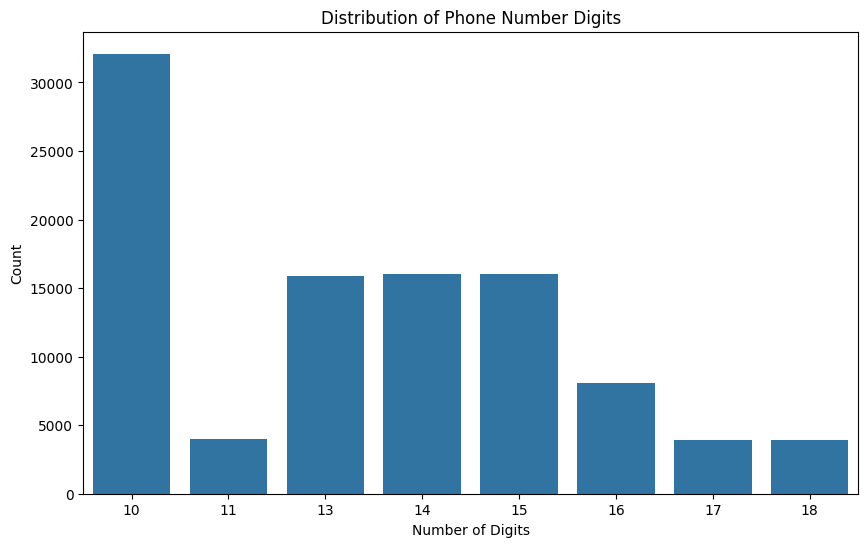

In [14]:
df["Phone Digits"] = df["Phone 1"].str.count(r'\d')
plt.figure(figsize=(10, 6))
sns.countplot(x="Phone Digits", data=df)
plt.title("Distribution of Phone Number Digits")
plt.xlabel("Number of Digits")
plt.ylabel("Count")

Phone numbers span from 10 to 18 digits, and based on the unique formats we examined, there's no consistent country coding, so to make use of this data, we might need to try finding a correlation between patterns to countries or domains

#### We identified two users from different cities and countries using the same email address to subscribe

Next perhaps we can find some seasonality from the dataset.
From the graph, there is a dip in subscriptions every February, but when grouping and aggregating the data, it might not be the case

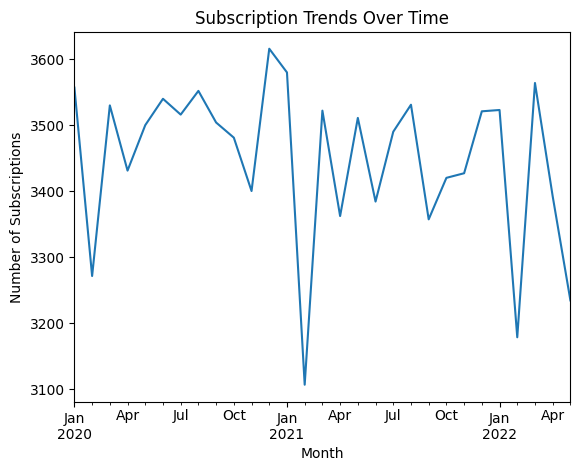

In [34]:
# identifying seasonality in subscription
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'], format='%Y-%m-%d', errors='coerce')
df.groupby(df['Subscription Date'].dt.to_period('M')).size().plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Number of Subscriptions')
plt.title('Subscription Trends Over Time')
plt.show()

In [35]:
monthly = df.groupby(df['Subscription Date'].dt.month).size()
print(monthly)  # aggregated across all years

Subscription Date
1     10660
2      9555
3     10616
4     10185
5     10245
6      6924
7      7006
8      7083
9      6861
10     6901
11     6827
12     7137
dtype: int64


In [36]:
print(df['Country'].value_counts())

Country
Congo               835
Korea               820
Saudi Arabia        463
Pitcairn Islands    456
Saint Martin        453
                   ... 
Moldova             371
Jordan              365
Saint Lucia         365
Slovenia            361
Greece              359
Name: count, Length: 243, dtype: int64


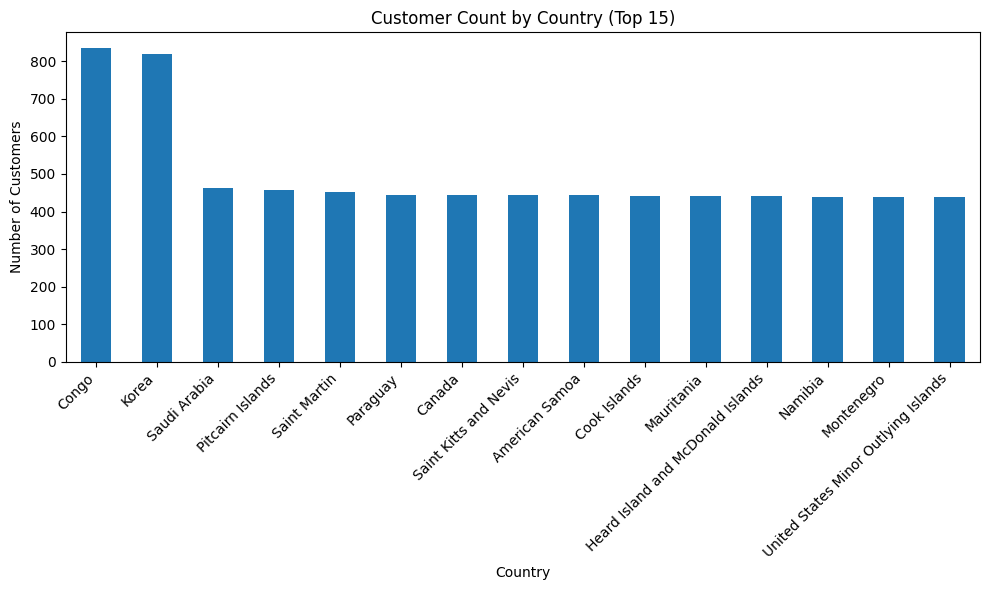

In [ ]:
country_counts = df['Country'].value_counts()

top_n = country_counts.head(15)

plt.figure(figsize=(10, 6))
top_n.plot(kind='bar')
plt.title('Customer Count by Country (Top 15)')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

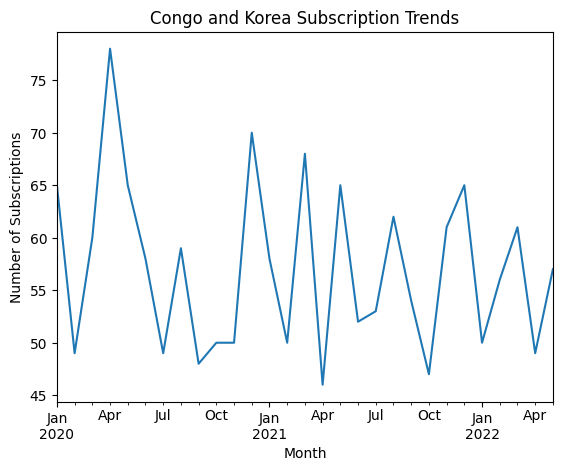

In [38]:
# Check if the biggest contributor countries have any seasonality of their own
df[df['Country'].isin(['Congo', 'Korea'])].groupby(df['Subscription Date'].dt.to_period('M')).size().plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Number of Subscriptions')
plt.title('Congo and Korea Subscription Trends')
plt.show()

No seasonality seems to be present in customer subscription trends from data evidence

### Insights Summary

### Part 2, 2000000 customer data

#### I am using Polars to process the data in this part, mainly to use the lazy querying technology it offers so we can explore the shape of the data, apply transformations and load at query time with streaming collection

In [60]:
import polars as pl
import tracemalloc

lazy_query = pl.scan_csv('customers-2000000.csv').with_columns( # maybe we can select a subset of columns to reduce memory usage
    pl.col('Index').cast(pl.Int32), 
    pl.col('Subscription Date').str.strptime(pl.Date, format='%Y-%m-%d', strict=False)
)
print(lazy_query.collect_schema())

Schema([('Index', Int32), ('Customer Id', String), ('First Name', String), ('Last Name', String), ('Company', String), ('City', String), ('Country', String), ('Phone 1', String), ('Phone 2', String), ('Email', String), ('Subscription Date', Date), ('Website', String)])


A few operations I added were casting the index to Int32 to conserve space and some other basic casts to simulate a data preprocessing pipeline

In [61]:
lazy_query

In [62]:
n_unique = (
    pl.scan_csv('customers-2000000.csv')
    .select(pl.col('Country').n_unique())
    .collect()
)
print(n_unique)

shape: (1, 1)
┌─────────┐
│ Country │
│ ---     │
│ u32     │
╞═════════╡
│ 243     │
└─────────┘


In [68]:
country_counts = (
    pl.scan_csv('customers-2000000.csv')
    .group_by('Country')
    .agg(pl.count())
    .sort('count', descending=True)
    .collect()
)
print(country_counts)

C:\Users\matth\AppData\Local\Temp\ipykernel_28536\2881747699.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count())


shape: (243, 2)
┌───────────────┬───────┐
│ Country       ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ Korea         ┆ 16240 │
│ Congo         ┆ 16208 │
│ Jordan        ┆ 8428  │
│ Vietnam       ┆ 8388  │
│ Suriname      ┆ 8375  │
│ …             ┆ …     │
│ French Guiana ┆ 7976  │
│ Eritrea       ┆ 7974  │
│ Iceland       ┆ 7965  │
│ Slovenia      ┆ 7964  │
│ Nicaragua     ┆ 7958  │
└───────────────┴───────┘


In [69]:
lazy_query = lazy_query.with_columns(
    pl.col('Country').cast(pl.Categorical)
)

#### Testing Run
Now I will test the collection of the query with streaming mode, and using tracemalloc to track the memory usage peaks and memory usage at the end

In [ ]:
tracemalloc.start()
result_df = lazy_query.collect(streaming=True)
current, peak = tracemalloc.get_traced_memory()
print(f"end=> Current memory usage: {current / 10**6}MB, Peak: {peak / 10**6}MB")
tracemalloc.stop()

C:\Users\matth\AppData\Local\Temp\ipykernel_28536\1434334112.py:2: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  result_df = lazy_query.collect(streaming=True)


end=> Current memory usage: 0.149974MB, Peak: 0.16025MB


In [72]:
print(result_df.head(10))

shape: (10, 12)
┌───────┬────────────┬────────────┬───────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ Index ┆ Customer   ┆ First Name ┆ Last Name ┆ … ┆ Phone 2    ┆ Email     ┆ Subscript ┆ Website   │
│ ---   ┆ Id         ┆ ---        ┆ ---       ┆   ┆ ---        ┆ ---       ┆ ion Date  ┆ ---       │
│ i32   ┆ ---        ┆ str        ┆ str       ┆   ┆ str        ┆ str       ┆ ---       ┆ str       │
│       ┆ str        ┆            ┆           ┆   ┆            ┆           ┆ date      ┆           │
╞═══════╪════════════╪════════════╪═══════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 1     ┆ 4962fdbE6B ┆ Pam        ┆ Sparks    ┆ … ┆ 480-078-05 ┆ nicolas00 ┆ 2020-11-2 ┆ https://n │
│       ┆ fee6D      ┆            ┆           ┆   ┆ 35x889     ┆ @faulkner ┆ 9         ┆ elson.com │
│       ┆            ┆            ┆           ┆   ┆            ┆ -kramer.c ┆           ┆ /         │
│       ┆            ┆            ┆           ┆   ┆            ┆ om        

I used 0.1 MB in Polars streaming compared to 980 MB from a traditional pandas read_csv

In [71]:
tracemalloc.start()
slow_db = pd.read_csv('customers-2000000.csv')
current, peak = tracemalloc.get_traced_memory()
print(f"end=> Current memory usage: {current / 10**6}MB, Peak: {peak / 10**6}MB")
tracemalloc.stop()

end=> Current memory usage: 986.422004MB, Peak: 1178.453707MB


## 3. Difference between splitting the large and small files